In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 資料增強和正規化
transform_train = transforms.Compose([
	transforms.RandomHorizontalFlip(),
	transforms.RandomCrop(32, padding=4),
	transforms.ToTensor(),
	transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
	transforms.ToTensor(),
	transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

In [3]:
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
# CIFAR-100 資料集
trainset = CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainset=CifarDataset(trainset)


validset = CIFAR100(root='./data', train=False, download=True, transform=transform_test)
validset=CifarDataset(validset)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# images=CifarDataset(cifar100_train)
# generator = torch.Generator()
# generator.manual_seed(125)

# size = len(images)
# valid_size = int(0.2 * size)

# train_size = int(size -valid_size)

# trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
# valid_size

In [8]:
# train_size

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

Epoch=0,train_loss=4.0861423565673824,train_accu=6.18%
Epoch=0,valid_loss=4.064529647064209,valid_accu=6.529999999999999%
0
Epoch=1,train_loss=3.824260587463379,train_accu=11.187999999999999%
Epoch=1,valid_loss=3.799265929412842,valid_accu=11.76%
0
Epoch=2,train_loss=3.594539221572876,train_accu=15.064%
Epoch=2,valid_loss=3.5660115852355956,valid_accu=16.0%
0
Epoch=3,train_loss=3.438306824798584,train_accu=17.83%
Epoch=3,valid_loss=3.3974833602905274,valid_accu=18.77%
0
Epoch=4,train_loss=3.332189963684082,train_accu=19.736%
Epoch=4,valid_loss=3.2975263175964353,valid_accu=20.54%
0
Epoch=5,train_loss=3.2312486684417725,train_accu=21.25%
Epoch=5,valid_loss=3.1926412559509276,valid_accu=22.53%
0
Epoch=6,train_loss=3.0869153869628905,train_accu=23.748%
Epoch=6,valid_loss=3.0530736991882326,valid_accu=25.16%
0
Epoch=7,train_loss=3.0245353203582765,train_accu=25.05%
Epoch=7,valid_loss=3.0001863162994384,valid_accu=25.580000000000002%
0
Epoch=8,train_loss=2.9676783520507812,train_accu=26.654

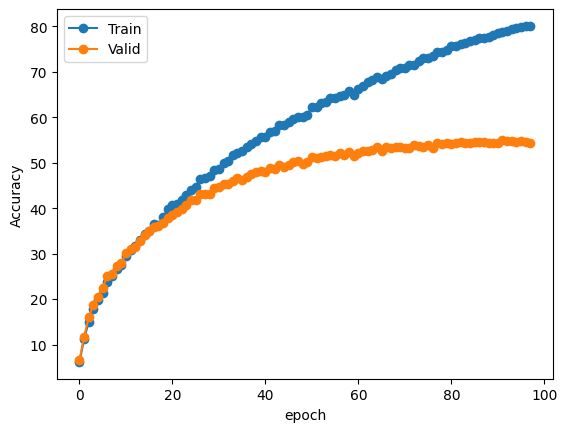

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",100)
# model_0 = torch.load(f'model_{model_algo}_0_67.pth')

In [11]:
train_size=len(trainset)
valid_size=len(validset)
train_size,valid_size

(50000, 10000)

In [12]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.7370605630016327, 0.7898)

In [13]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.7961362730026245, 0.5488)

In [14]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [15]:
each_accu=p
each_accu=each_accu.sort_values(ascending=True)
each_accu

otter        0.434
seal         0.510
squirrel     0.534
girl         0.536
bear         0.554
             ...  
chair        0.946
rocket       0.946
wardrobe     0.948
sunflower    0.956
road         0.962
Length: 100, dtype: float64

In [16]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.910521
aquarium_fish    0.878143
baby             0.727273
bear             0.610132
beaver           0.667411
                   ...   
whale            0.814739
willow_tree      0.777996
wolf             0.736337
woman            0.658325
worm             0.818182
Length: 100, dtype: float64

In [17]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements[:N], top_positions[:N]

In [18]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=50)

Top 50 Elements:
[0.252 0.212 0.18  0.16  0.14  0.138 0.138 0.128 0.126 0.124 0.122 0.12
 0.118 0.11  0.108 0.102 0.1   0.1   0.098 0.094 0.094 0.092 0.09  0.086
 0.084 0.084 0.082 0.082 0.08  0.078 0.076 0.076 0.074 0.074 0.074 0.072
 0.07  0.07  0.068 0.068 0.068 0.066 0.066 0.064 0.062 0.06  0.06  0.06
 0.06  0.058]
Top 50 Positions:
[(52, 47), (98, 35), (35, 11), (98, 46), (92, 70), (92, 62), (73, 30), (73, 67), (95, 30), (81, 13), (72, 55), (59, 52), (46, 11), (35, 2), (21, 3), (11, 2), (58, 13), (70, 62), (25, 5), (74, 50), (61, 10), (96, 47), (98, 11), (61, 22), (96, 33), (95, 73), (24, 7), (71, 23), (96, 52), (88, 42), (74, 4), (37, 17), (99, 78), (88, 34), (71, 60), (96, 59), (44, 27), (67, 32), (92, 54), (97, 66), (46, 35), (46, 2), (44, 18), (90, 81), (72, 3), (50, 36), (80, 38), (83, 53), (45, 26), (66, 64)]


In [19]:
unique_elements = set()

# 遍历所有的元组，并将每个元素添加到集合中
for pair in top_positions:
    unique_elements.update(pair)
    if(len(unique_elements)>=40):
        break

unique_list = list(unique_elements)

print(len(unique_list))    

40


In [20]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',40)

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(trainset, indexF)
Tdataset=Subset(trainset, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(20000, 30000)

In [21]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(4000, 6000)

In [22]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
# class_counts = [0, 0]
# for _,_,label,_ in trainset:
#     class_counts[label] +=1

In [25]:
# # 计算每个类别的权重
# class_weights = [1.0 / count for count in class_counts]
# weights = torch.FloatTensor(class_weights).cuda()

Epoch=0,train_loss=0.4464791494655609,train_accu=78.64%
Epoch=0,valid_loss=0.4886318902254105,valid_accu=75.69%
0
Epoch=1,train_loss=0.4095739948749542,train_accu=80.74799999999999%
Epoch=1,valid_loss=0.4711706972122192,valid_accu=76.85%
0
Epoch=2,train_loss=0.39665245792388915,train_accu=81.772%
Epoch=2,valid_loss=0.46584084496498107,valid_accu=77.35%
0
Epoch=3,train_loss=0.37628405457496644,train_accu=82.714%
Epoch=3,valid_loss=0.45399049010276793,valid_accu=77.78%
0
Epoch=4,train_loss=0.36745325058937073,train_accu=83.578%
Epoch=4,valid_loss=0.4560147808551788,valid_accu=77.66999999999999%
EarlyStopping counter: 1 out of 6
Epoch=5,train_loss=0.3446951488494873,train_accu=84.564%
Epoch=5,valid_loss=0.4536579418182373,valid_accu=78.14999999999999%
0
Epoch=6,train_loss=0.3412690181922913,train_accu=85.042%
Epoch=6,valid_loss=0.4450911817073822,valid_accu=78.5%
0
Epoch=7,train_loss=0.32892461342811585,train_accu=85.71%
Epoch=7,valid_loss=0.45209614634513856,valid_accu=78.34%
EarlyStoppi

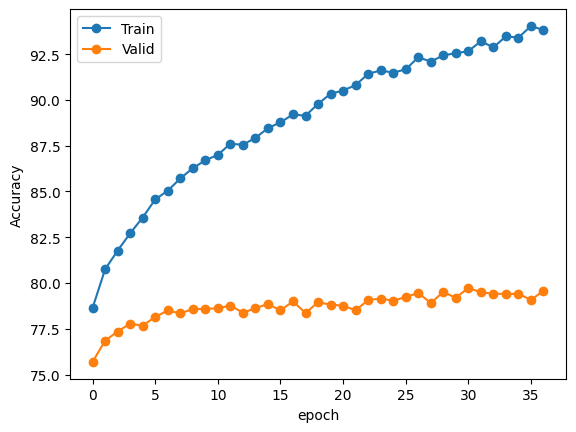

In [26]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",100,model_0=model_0)
# model_decision = torch.load(f'model_{model_algo}_decision_24.pth')

In [27]:
Fdataset_v=Subset(validset, indexF_v)
Tdataset_v=Subset(validset, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=1.1529907032648723,train_accu=68.28%
Epoch=0,valid_loss=1.4041499265034993,valid_accu=62.18333333333334%
0
Epoch=1,train_loss=0.8640558512369791,train_accu=75.44999999999999%
Epoch=1,valid_loss=1.237342605113983,valid_accu=66.86666666666666%
0
Epoch=2,train_loss=0.7392183581829072,train_accu=78.66%
Epoch=2,valid_loss=1.1814853601455688,valid_accu=67.85%
0
Epoch=3,train_loss=0.6363427331288656,train_accu=81.32000000000001%
Epoch=3,valid_loss=1.1268589275677998,valid_accu=68.51666666666667%
0
Epoch=4,train_loss=0.5800482088406881,train_accu=82.89333333333333%
Epoch=4,valid_loss=1.1168381764094035,valid_accu=69.58333333333333%
0
Epoch=5,train_loss=0.5362744121551514,train_accu=84.26%
Epoch=5,valid_loss=1.1094643290837605,valid_accu=69.73333333333333%
0
Epoch=6,train_loss=0.5010819412549337,train_accu=85.21%
Epoch=6,valid_loss=1.1084948089917501,valid_accu=69.83333333333334%
0
Epoch=7,train_loss=0.4763569986661275,train_accu=85.83%
Epoch=7,valid_loss=1.1013989453315736,v

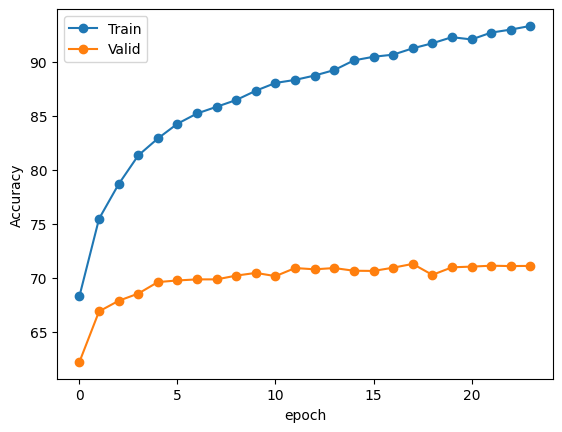

In [28]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",100,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.747788946723938,train_accu=51.705%
Epoch=0,valid_loss=2.0470345287322997,valid_accu=41.975%
0
Epoch=1,train_loss=1.4079726517677307,train_accu=59.785%
Epoch=1,valid_loss=1.856963819503784,valid_accu=47.85%
0
Epoch=2,train_loss=1.2223004483222961,train_accu=64.875%
Epoch=2,valid_loss=1.7829185075759888,valid_accu=49.675000000000004%
0
Epoch=3,train_loss=1.0996661809921264,train_accu=68.30000000000001%
Epoch=3,valid_loss=1.7657524280548096,valid_accu=50.775000000000006%
0
Epoch=4,train_loss=1.0241491421699525,train_accu=70.785%
Epoch=4,valid_loss=1.7481171655654908,valid_accu=50.324999999999996%
EarlyStopping counter: 1 out of 6
Epoch=5,train_loss=0.9461758034229278,train_accu=72.28%
Epoch=5,valid_loss=1.7458306679725646,valid_accu=51.025%
0
Epoch=6,train_loss=0.9027575540065765,train_accu=73.83%
Epoch=6,valid_loss=1.7606670160293578,valid_accu=50.55%
EarlyStopping counter: 1 out of 6
Epoch=7,train_loss=0.8408084677219391,train_accu=75.115%
Epoch=7,valid_loss=1.77172

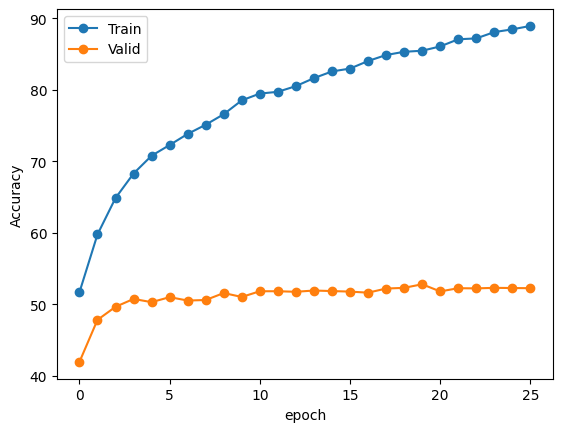

In [29]:
#訓練模型T、F、decision
model_F=model_train(model_algo,Fdl,Fdl_v,"F",100,model_0=model_0)
# model_F=torch.load(f'model_{model_algo}_F_1.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.1893744344305992, 0.9288)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.5017646334648133, 0.7974)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.29396046750942867, 0.9143333333333333)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.5172098966598511, 0.8512)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.1080691680908203, 0.7126666666666667)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.8642636713981628, 0.52825)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.38291896292209626, 0.89096, 20000)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.4105468717575074, 0.6389, 4000)

In [38]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t in zip(data,target):
                
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                out=model_0(d.unsqueeze(0))
                _, pred_0= torch.max(out, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [39]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(1.3671185691916943, 0.82754, 19490, 30510)

In [40]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(3.921657795715332, 0.539, 3782, 6218)

In [41]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [42]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classaccu', [55, 72, 80, 35, 3, 50, 4, 46, 44, 11, 93, 10, 65, 64, 74, 98, 25, 47, 92, 29, 77, 78, 79, 15, 22, 19, 38, 2, 73, 84, 59, 18, 67, 13, 33, 42, 32, 45, 30, 97])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.737061,0.789800,1.796136,0.548800
1,Model_Decision,0.189374,0.928800,0.501765,0.797400
2,Model_T,0.293960,0.914333,1.108069,0.712667
3,Model_F,0.517210,0.851200,1.864264,0.528250
4,Total_Model,1.367119,0.827540,3.921658,0.539000
5,Total_Model_with_perfect_decision,0.382919,0.890960,1.410547,0.638900


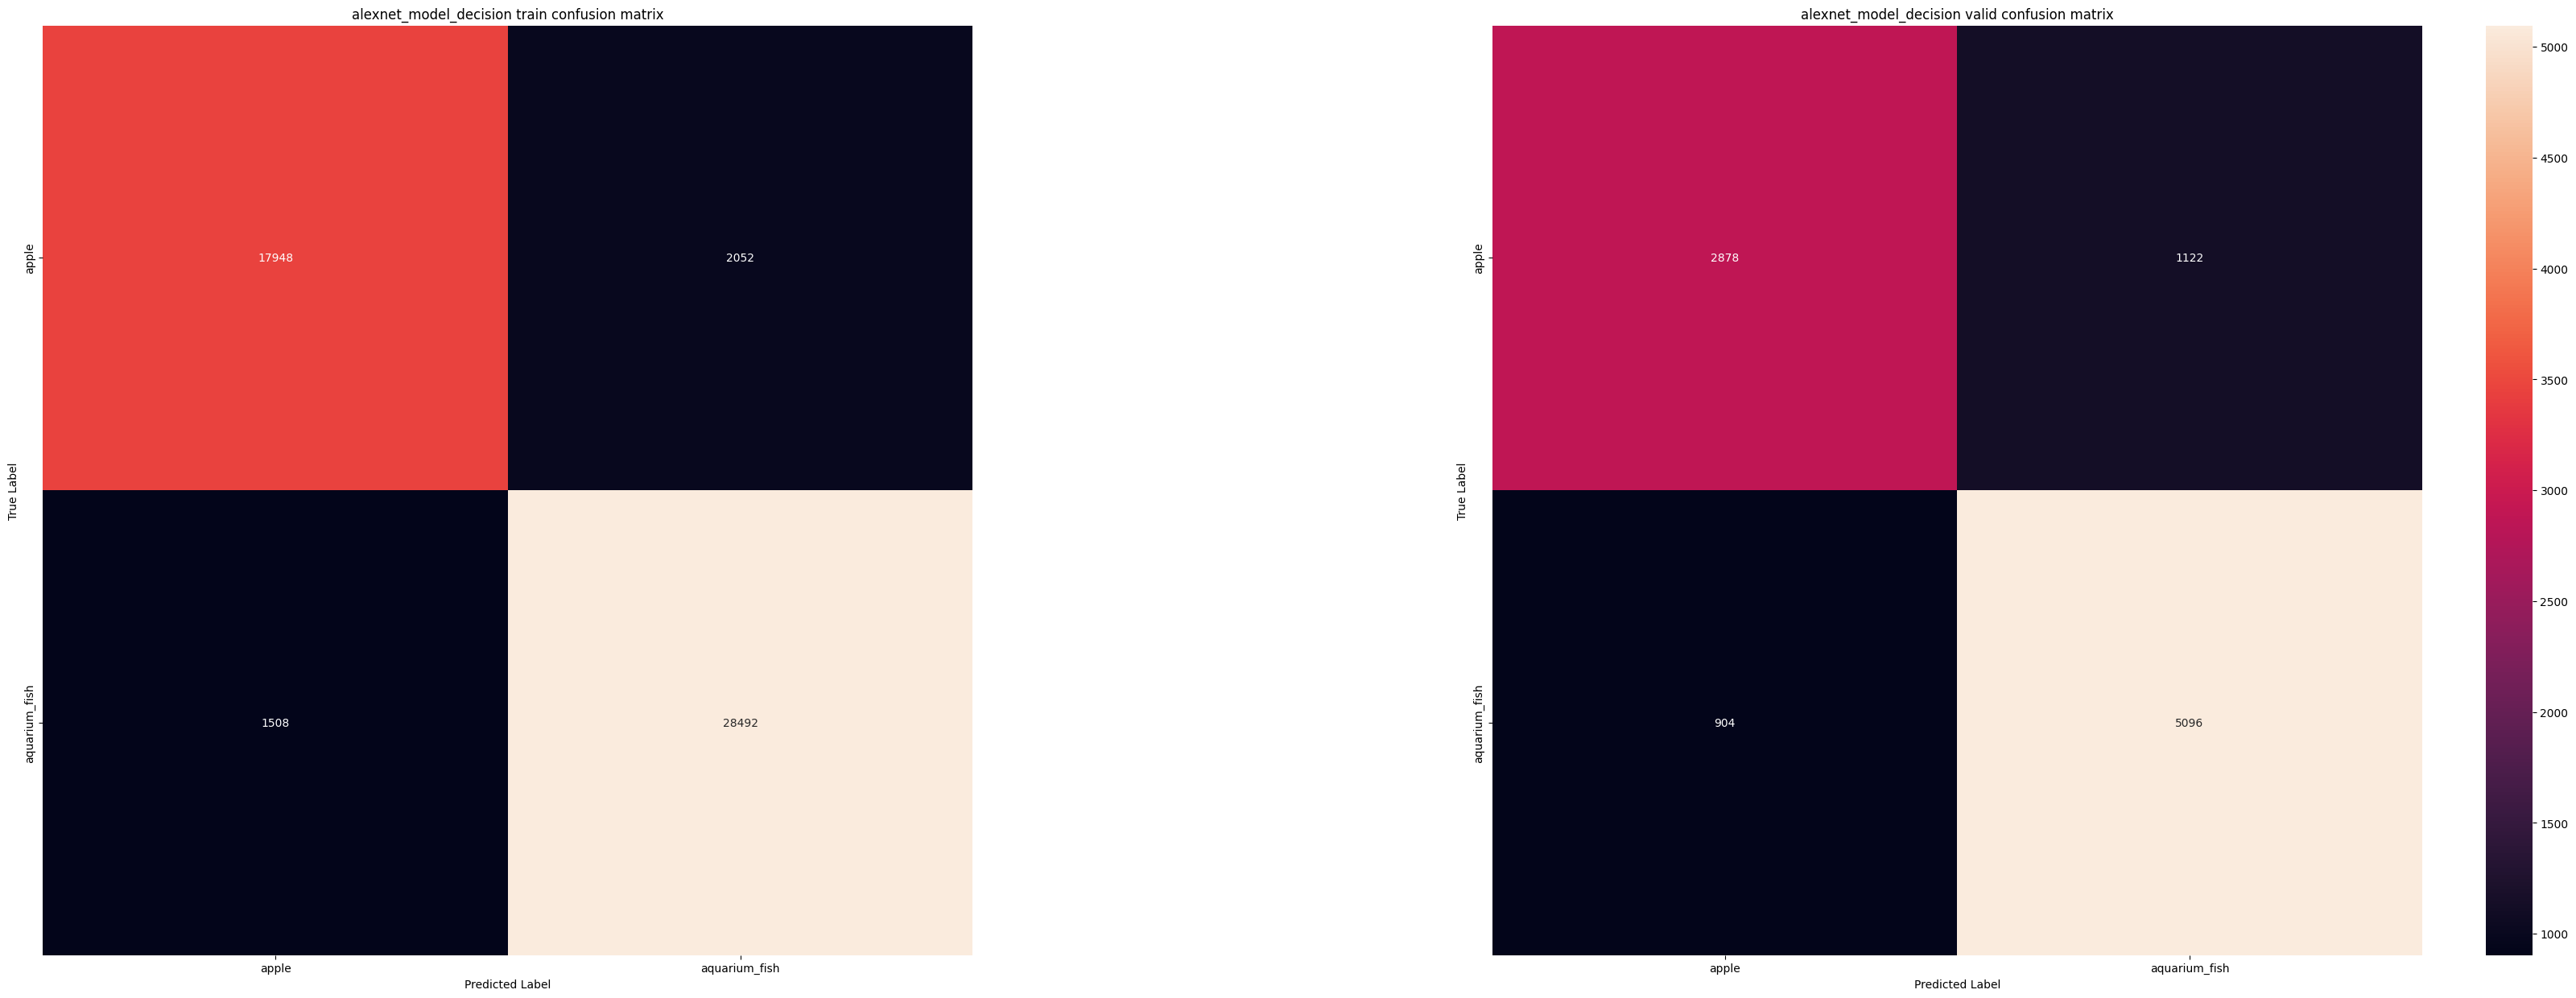

In [43]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

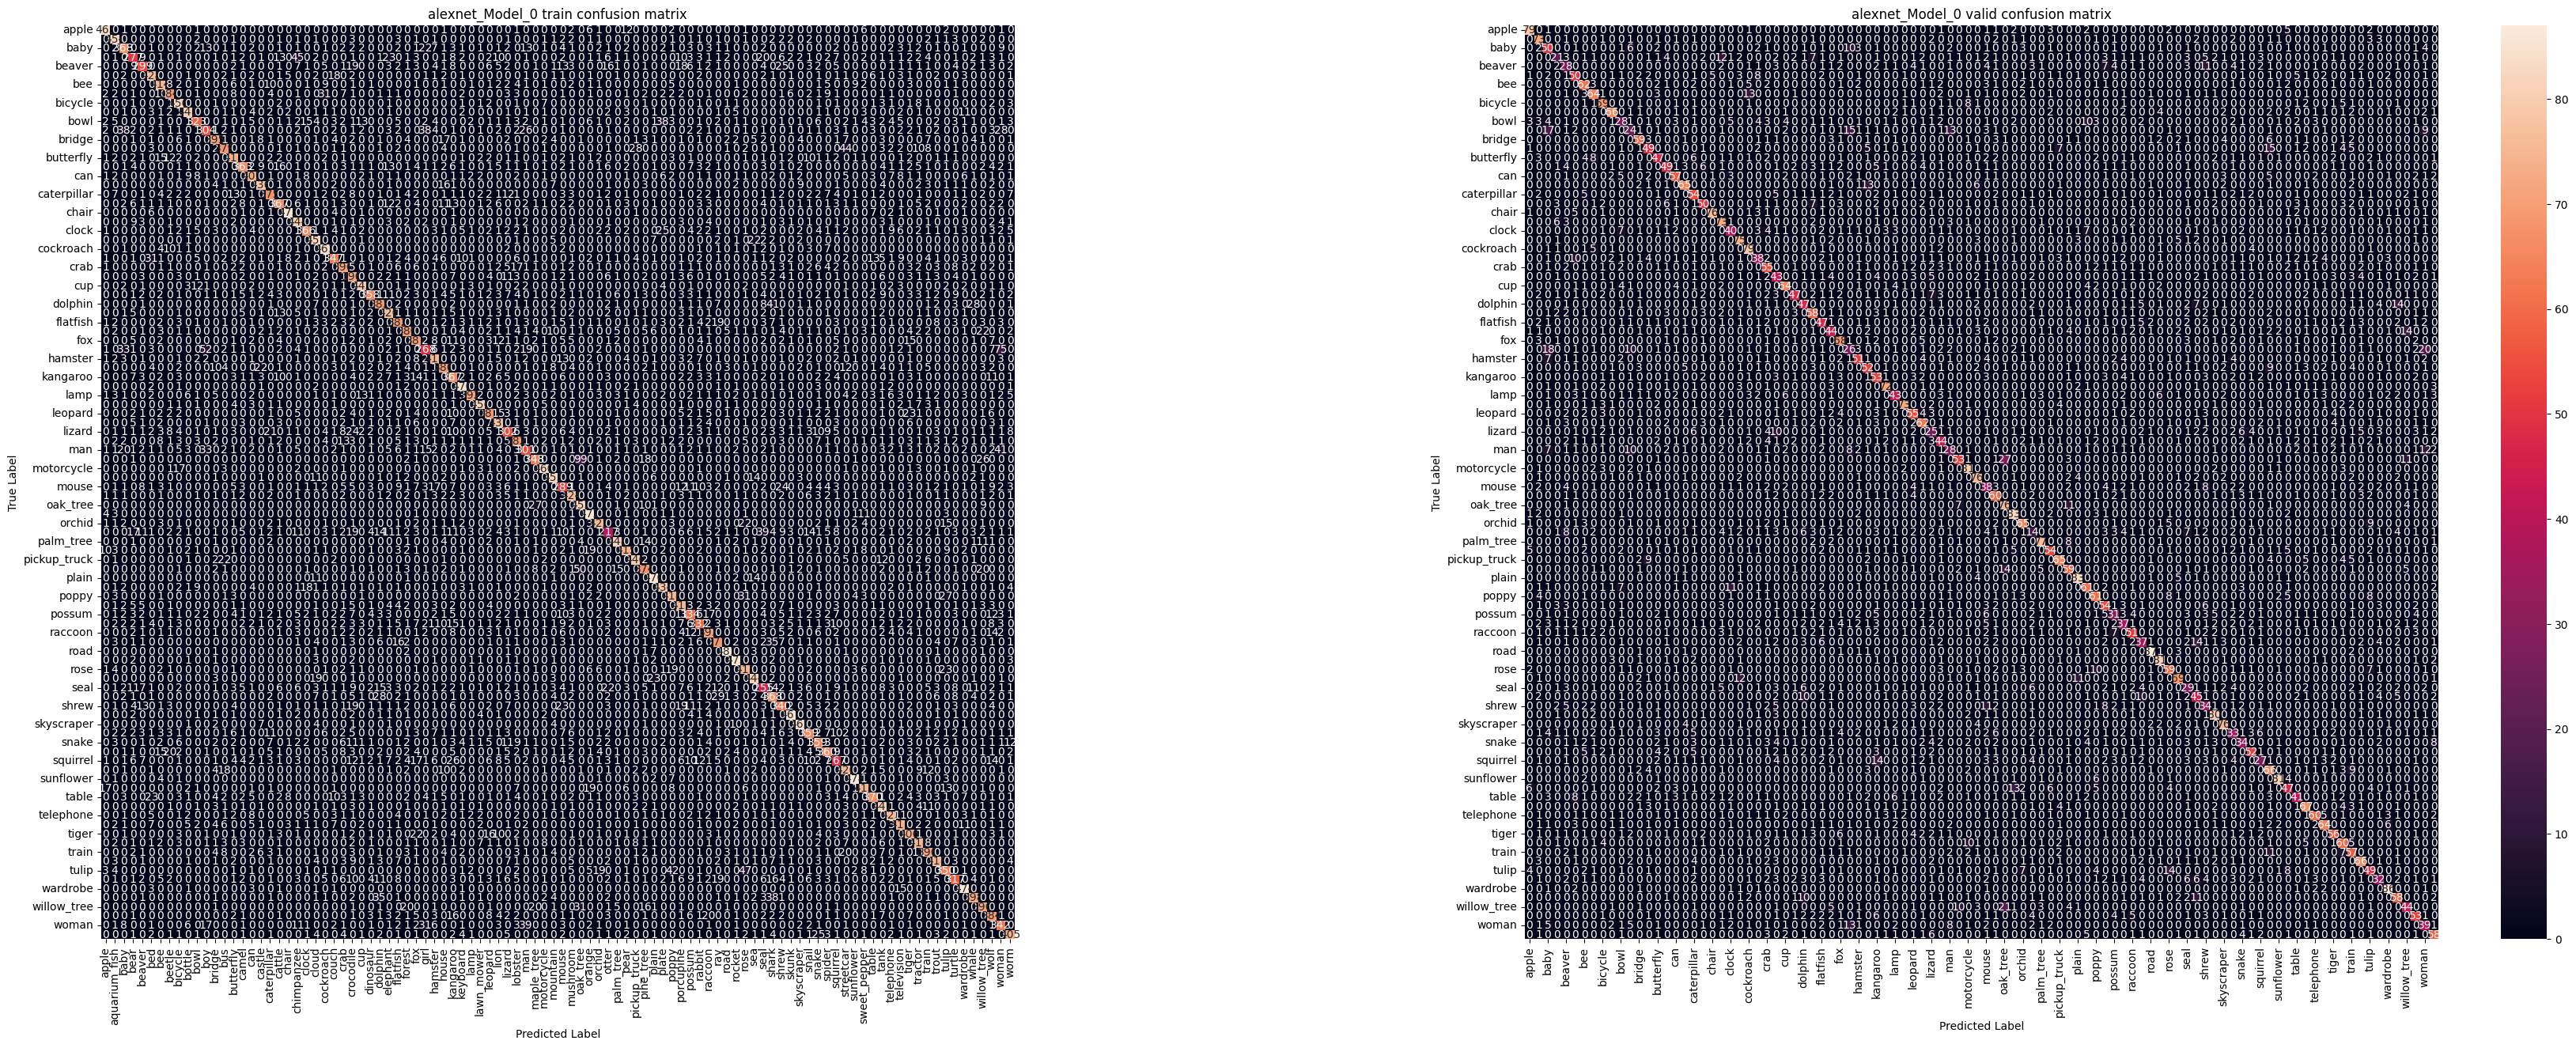

In [44]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

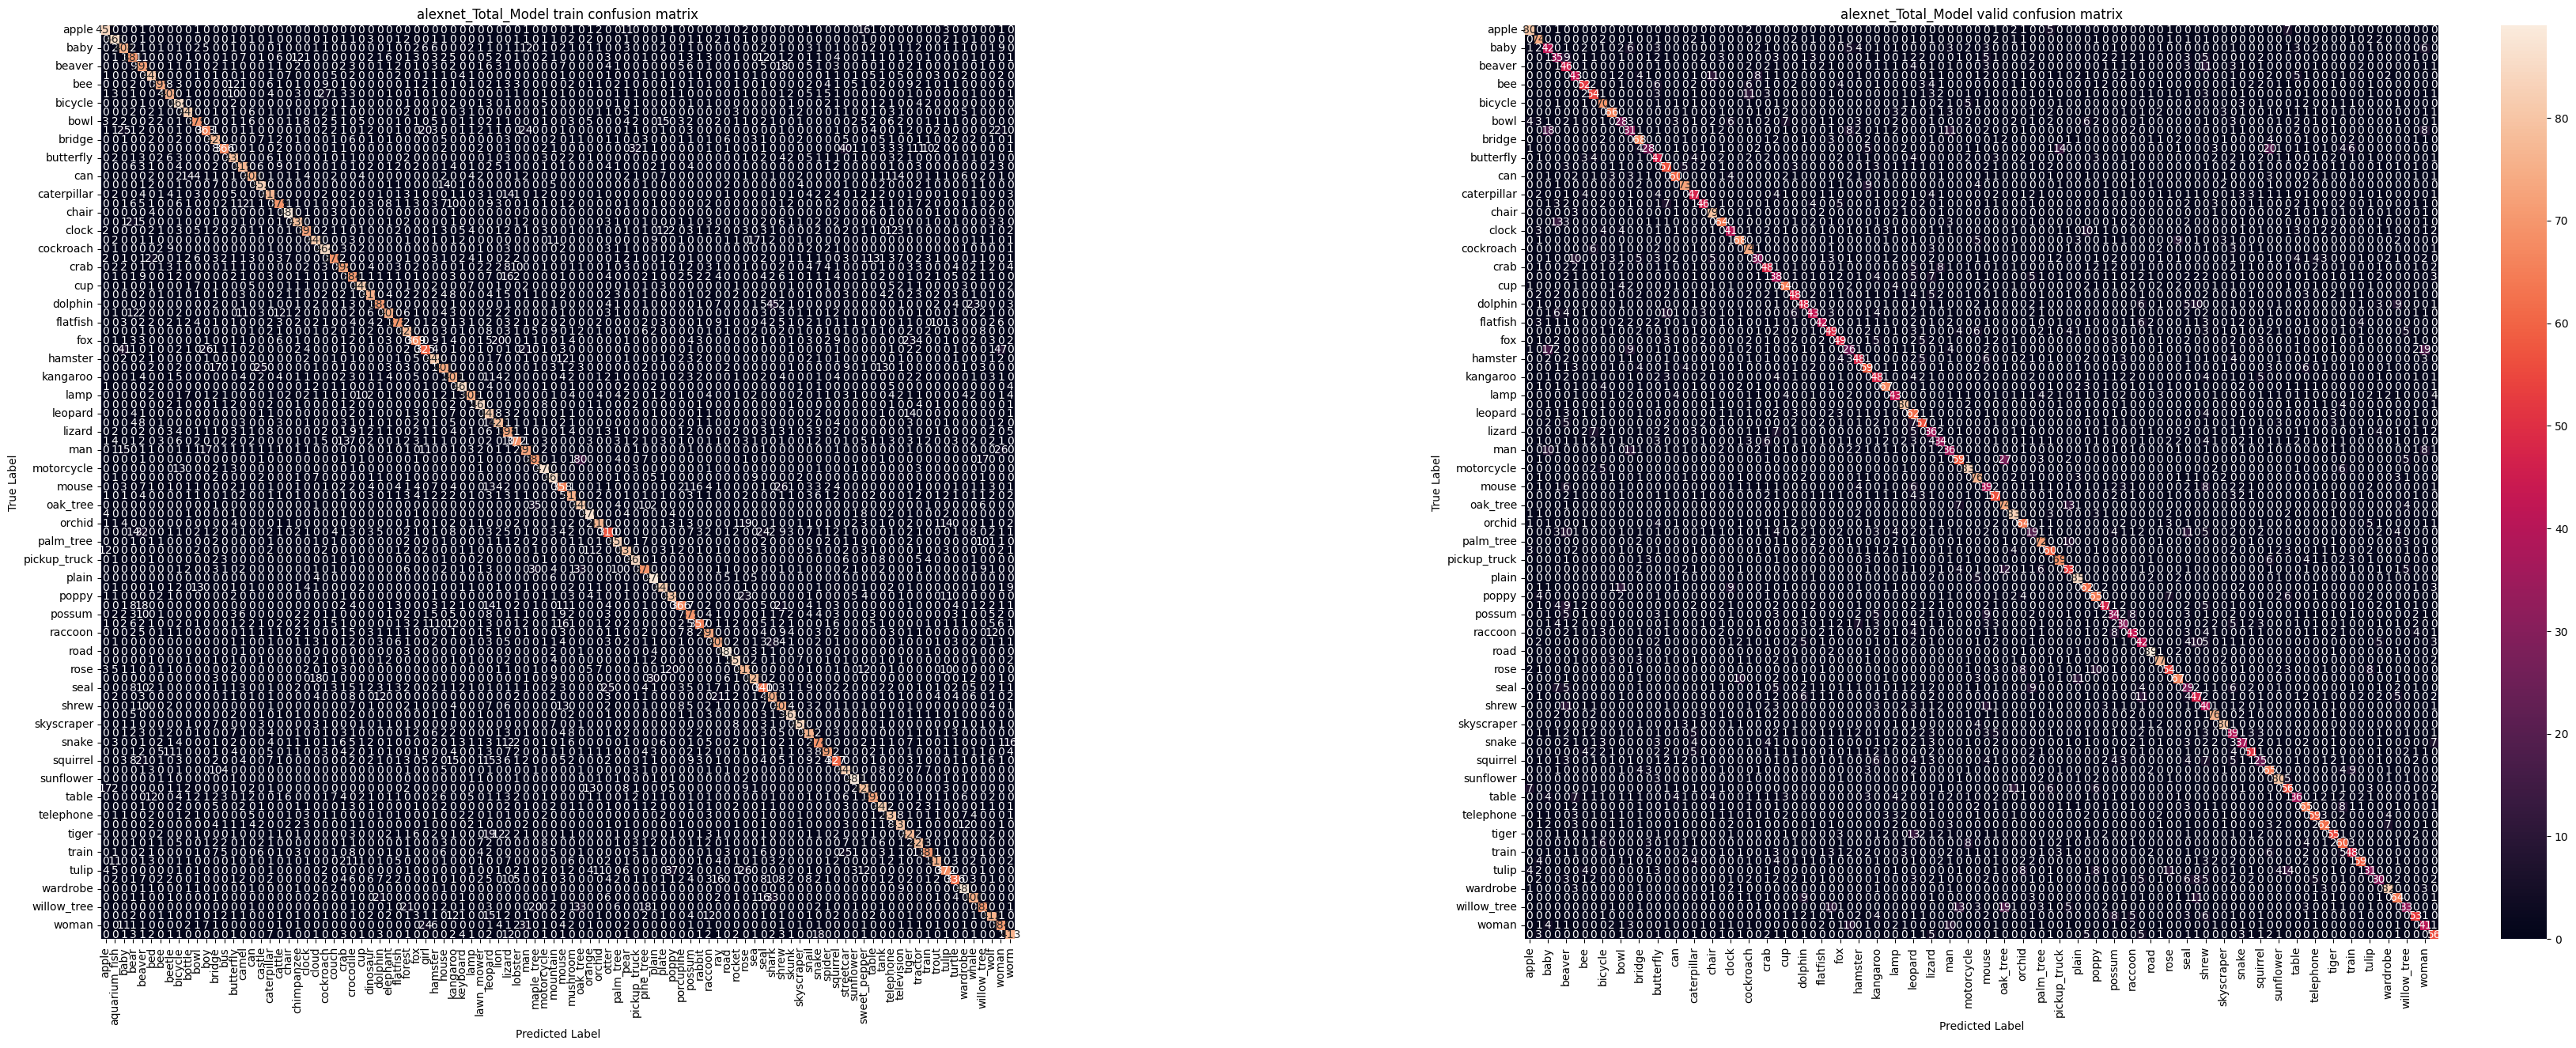

In [45]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

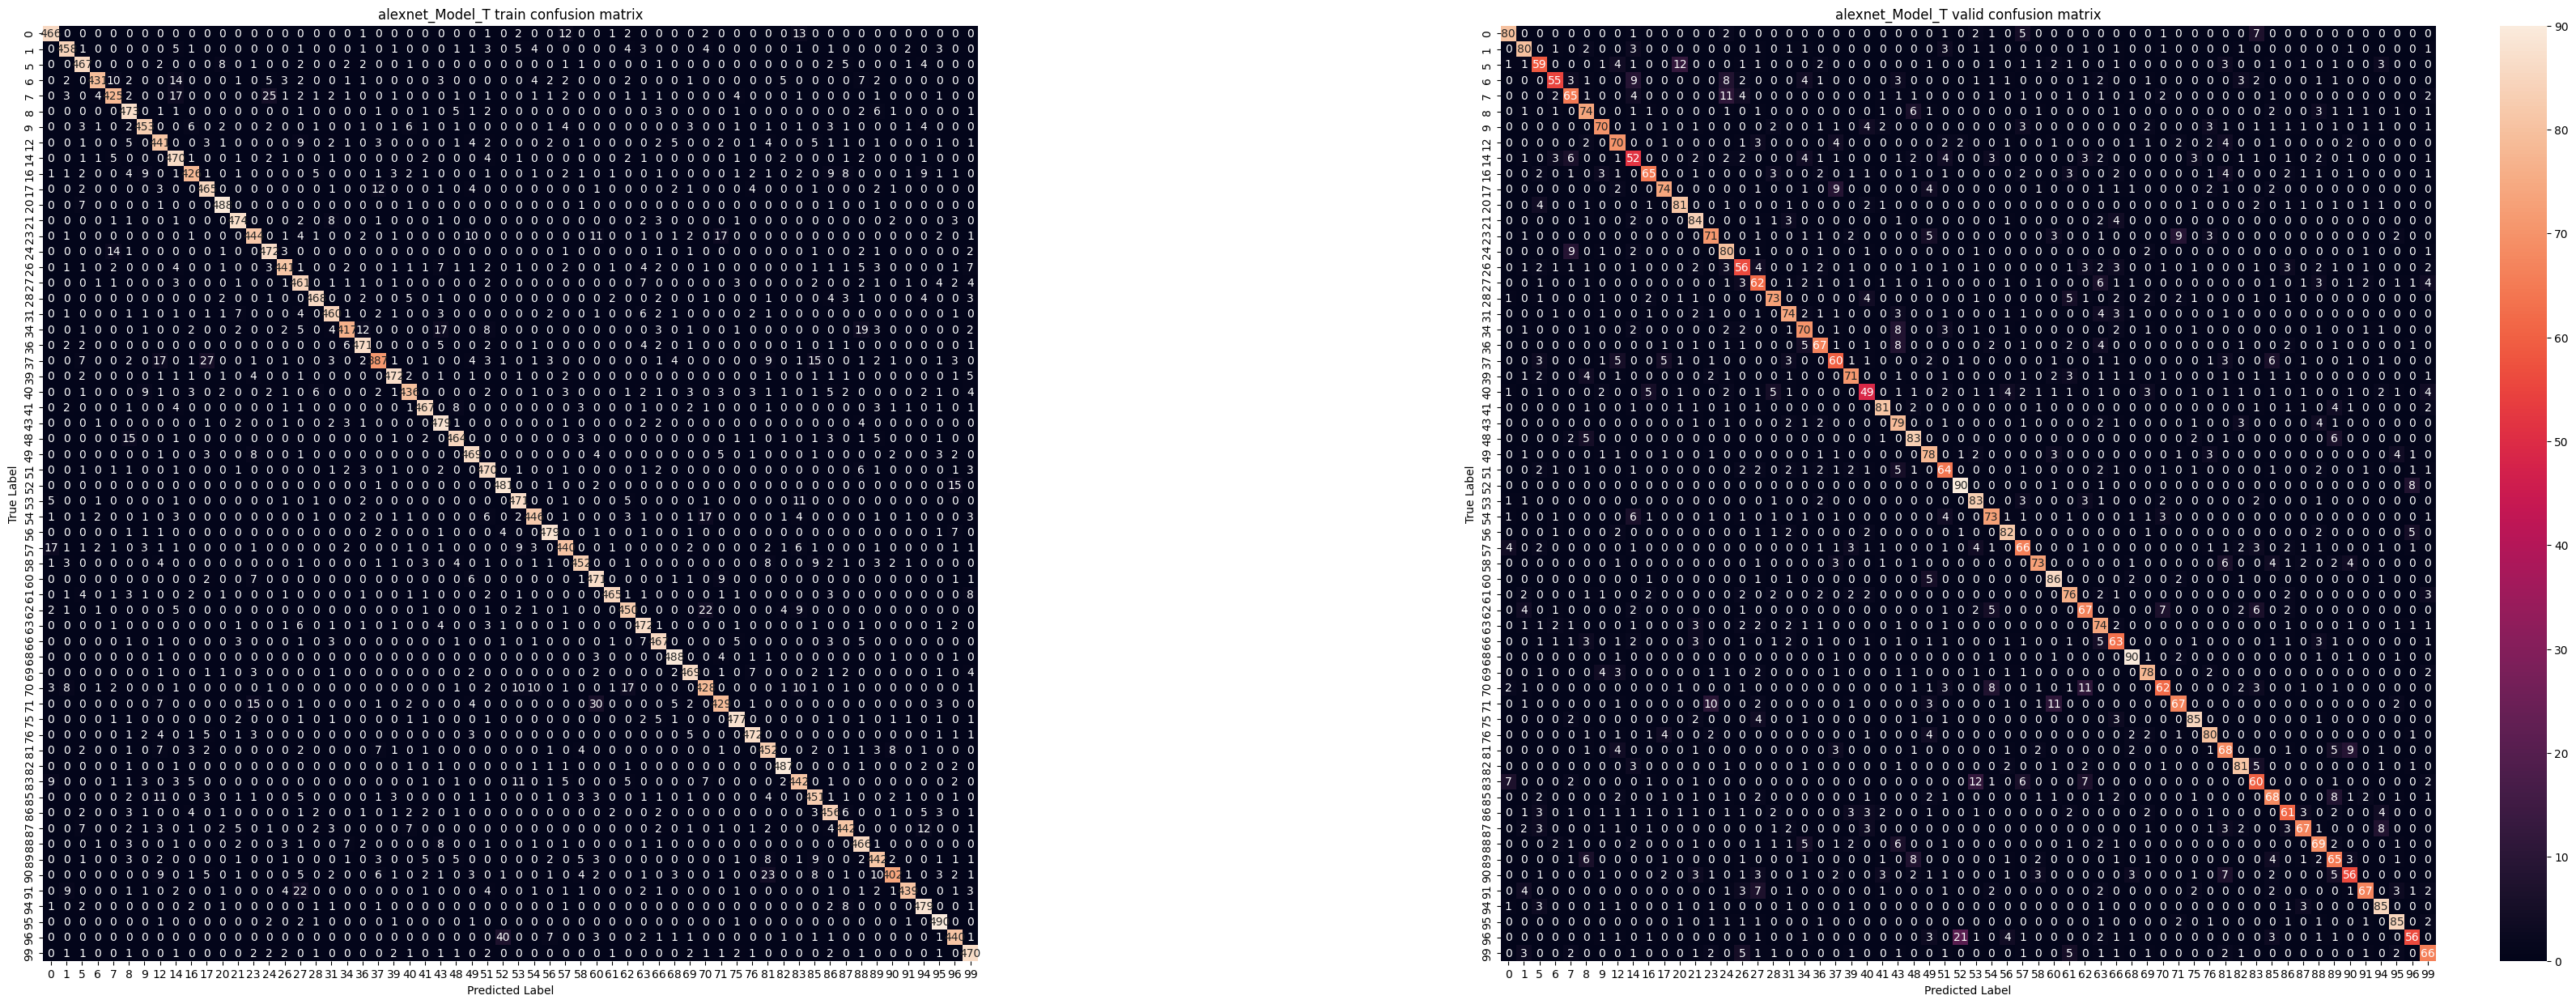

In [46]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

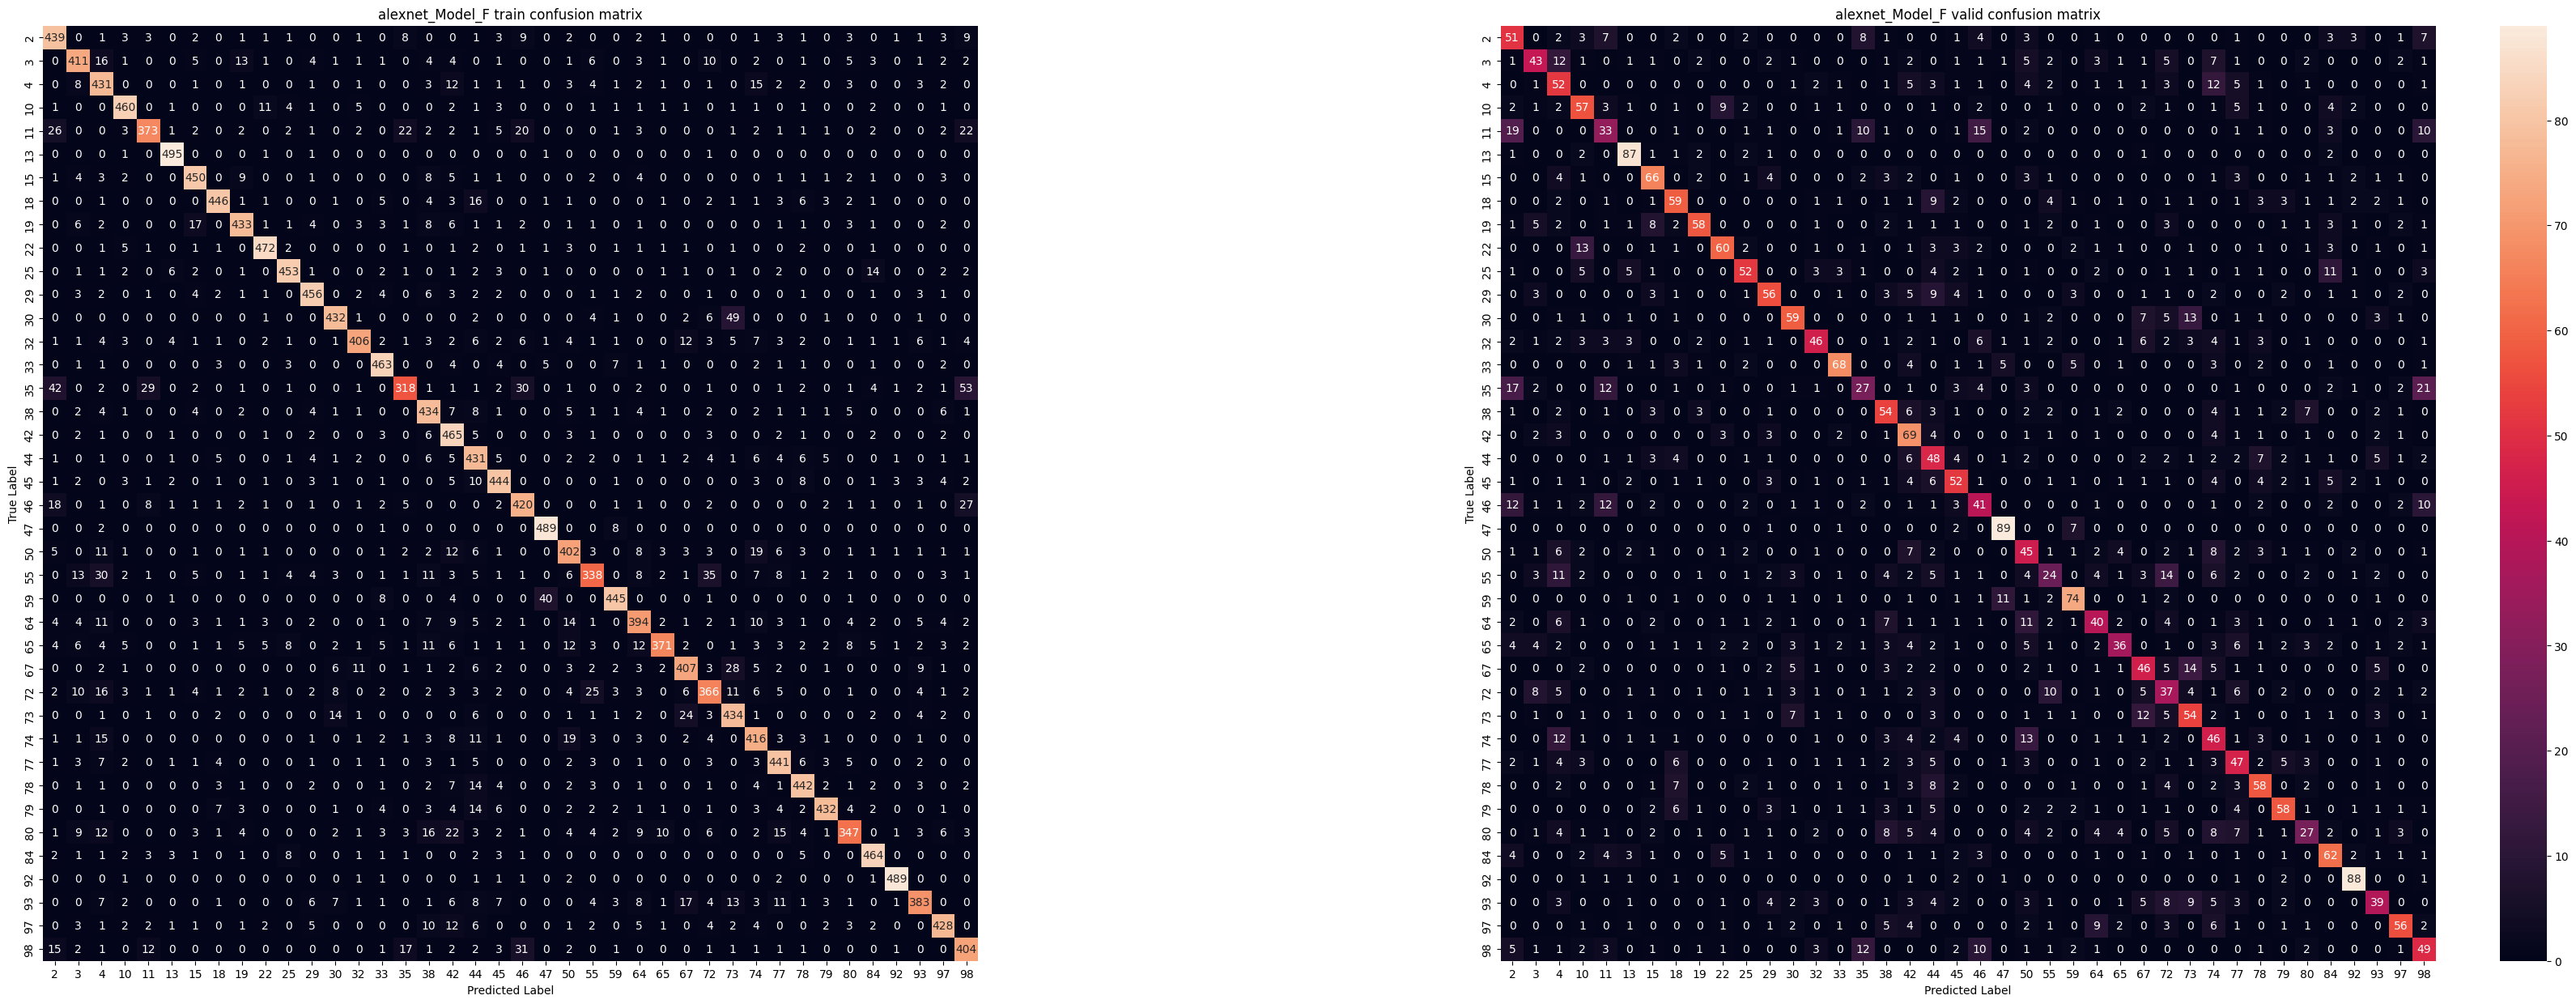

In [47]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [48]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.flag[idx],
                    'Match_d': bool(pred_decision) == data_dl.dataset.flag[idx]
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [49]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
0,24790,23,73,23,23,0.568880,0.995825,0.987188,0.995324,False,True,True,True,True,True
1,32469,63,74,63,63,0.502054,0.998567,0.997232,0.998958,False,True,True,True,True,True
2,19351,48,13,48,48,0.621904,0.939036,0.818838,0.998938,False,True,True,True,True,True
3,49128,69,79,69,69,0.225376,0.998299,0.999038,0.999865,False,True,True,True,True,True
4,38224,43,4,36,43,0.707047,0.498746,0.534963,0.925370,False,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,43157,41,19,41,41,0.499917,0.992159,0.903090,0.994787,False,True,True,True,True,True
49996,1873,35,46,8,98,0.664630,0.253568,0.366890,0.922496,False,False,False,False,False,True
49997,41278,99,44,99,39,0.384492,0.713329,0.454051,0.659169,False,True,False,True,True,True
49998,19091,72,73,99,73,0.657735,0.307979,0.434137,0.915516,False,False,False,False,False,True


In [50]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
5,5193,10,98,57,57,0.218825,0.603011,0.388475,0.805611,False,False,False,True,False,False
8,21084,52,47,52,52,0.938745,0.932465,0.626036,0.700447,False,True,True,True,True,True
9,33604,25,25,87,87,0.336844,0.251010,0.339972,0.533728,True,False,False,False,False,True
10,14578,81,13,81,81,0.947290,0.844937,0.572530,0.880914,False,True,True,True,True,True
11,47877,96,59,96,96,0.571423,0.993595,0.950693,0.737256,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49984,32413,62,92,62,92,0.964108,0.939617,0.485349,0.857316,False,True,False,True,True,True
49989,7986,30,30,95,30,0.783179,0.952102,0.536996,0.806512,True,False,True,False,False,True
49992,22850,99,92,1,92,0.998339,0.416126,0.539196,0.848072,False,False,False,True,True,True
49997,41278,99,44,99,39,0.384492,0.713329,0.454051,0.659169,False,True,False,True,True,True


In [51]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
5,5193,10,98,57,57,0.218825,0.603011,0.388475,0.805611,False,False,False,True,False,False
17,28946,63,59,63,63,0.238290,0.873624,0.469554,0.556510,False,True,True,False,True,False
24,18861,24,77,24,77,0.894059,0.278121,0.689395,0.777397,False,True,False,False,True,False
53,46527,29,29,88,29,0.985900,0.811221,0.853620,0.555672,True,False,True,True,False,False
103,755,33,33,49,60,0.990085,0.427708,0.388058,0.676080,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49944,33828,90,30,27,27,0.714729,0.687561,0.199746,0.682266,False,False,False,False,True,False
49948,24725,16,45,16,45,0.751098,0.504713,0.448977,0.512320,False,True,False,False,True,False
49949,43534,59,59,52,59,0.877860,0.987826,0.499236,0.721224,True,False,True,True,False,False
49978,47742,13,13,58,13,0.994570,0.977714,0.621670,0.805512,True,False,True,True,False,False


In [52]:
df_results[(df_results['Decision']==df_results['flag'])&(df_results['Softmax_decision']<0.9)&(df_results['Softmax_F']>df_results['Softmax_T'])&(df_results['Match_F']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
8,21084,52,47,52,52,0.938745,0.932465,0.626036,0.700447,False,True,True,True,True,True
10,14578,81,13,81,81,0.947290,0.844937,0.572530,0.880914,False,True,True,True,True,True
30,4598,70,92,70,70,0.994877,0.580188,0.517654,0.713798,False,True,True,True,True,True
54,21333,22,10,39,10,0.780403,0.613968,0.784955,0.776047,False,False,False,False,False,True
65,31887,5,84,5,5,0.990752,0.974736,0.611228,0.820345,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49868,41163,52,47,96,52,0.692130,0.534762,0.365082,0.884342,False,False,True,True,True,True
49872,24681,96,47,96,47,0.983133,0.773535,0.489625,0.749300,False,True,False,True,True,True
49968,9540,58,13,16,13,0.764649,0.356114,0.313289,0.876358,False,False,False,True,True,True
49984,32413,62,92,62,92,0.964108,0.939617,0.485349,0.857316,False,True,False,True,True,True


In [53]:
df_results[(df_results['Match_T']!=True)&(df_results['Softmax_T']>0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
23,45535,55,55,24,55,0.643637,0.974808,0.512815,0.991651,True,False,True,False,False,True
34,30361,46,2,36,11,0.408439,0.985094,0.311211,0.999999,False,False,False,False,False,True
70,36108,33,33,68,68,0.988825,0.999999,0.999743,0.521108,True,False,False,False,False,True
93,35622,84,84,5,84,0.999832,0.928819,0.988958,0.996729,True,False,True,False,False,True
109,609,30,73,95,95,0.465834,0.996195,0.343196,0.670962,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49973,44208,92,92,83,92,0.999765,0.921780,0.860491,0.979199,True,False,True,False,False,True
49978,47742,13,13,58,13,0.994570,0.977714,0.621670,0.805512,True,False,True,True,False,False
49981,12570,67,67,23,67,0.989625,0.961765,0.920329,0.994863,True,False,True,False,False,True
49989,7986,30,30,95,30,0.783179,0.952102,0.536996,0.806512,True,False,True,False,False,True


In [54]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

92    134
13    130
63    117
47    113
10    104
     ... 
82      3
49      3
53      3
71      3
94      2
Name: Target, Length: 98, dtype: int64

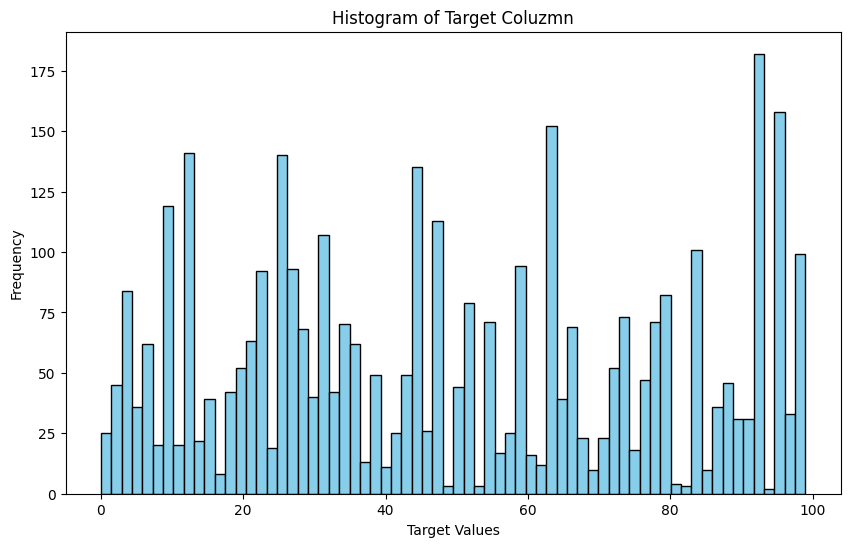

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
0,4629,61,22,61,61,0.647427,0.999664,0.672979,0.903138,False,True,True,False,True,False
1,6676,93,93,86,62,0.805196,0.390407,0.321100,0.788768,True,False,False,True,False,False
2,5083,10,78,61,61,0.986324,0.986128,0.421187,0.934662,False,False,False,True,False,False
3,8120,1,92,1,1,0.260420,0.999975,0.995917,0.850260,False,True,True,True,True,True
4,9553,64,98,62,62,0.161086,0.833221,0.294105,0.603245,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4108,74,74,63,74,0.805523,0.892656,0.735146,0.999763,True,False,True,False,False,True
9996,7600,95,30,95,95,0.936727,0.999998,0.997076,0.999466,False,True,True,True,True,True
9997,5581,17,33,17,17,0.611418,0.966243,0.729971,0.986955,False,True,True,True,True,True
9998,4573,28,11,28,21,0.261959,0.708104,0.262851,0.996520,False,True,False,True,True,True


In [57]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
1,6676,93,93,86,62,0.805196,0.390407,0.321100,0.788768,True,False,False,True,False,False
3,8120,1,92,1,1,0.260420,0.999975,0.995917,0.850260,False,True,True,True,True,True
4,9553,64,98,62,62,0.161086,0.833221,0.294105,0.603245,False,False,False,True,False,False
5,2758,74,4,21,4,0.334457,0.430299,0.140684,0.773086,False,False,False,False,False,True
6,1346,59,59,56,59,0.994384,0.537359,0.945785,0.827944,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,9329,63,42,63,63,0.701801,0.589221,0.360039,0.811979,False,True,True,True,True,True
9988,447,22,42,88,78,0.342108,0.205805,0.148259,0.577173,False,False,False,True,False,False
9990,9758,38,19,51,19,0.215628,0.554017,0.417969,0.767493,False,False,False,False,False,True
9992,4783,32,65,21,32,0.464213,0.817443,0.341882,0.773378,False,False,True,False,False,True


In [58]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
0,4629,61,22,61,61,0.647427,0.999664,0.672979,0.903138,False,True,True,False,True,False
1,6676,93,93,86,62,0.805196,0.390407,0.321100,0.788768,True,False,False,True,False,False
2,5083,10,78,61,61,0.986324,0.986128,0.421187,0.934662,False,False,False,True,False,False
4,9553,64,98,62,62,0.161086,0.833221,0.294105,0.603245,False,False,False,True,False,False
9,1352,33,42,43,42,0.792643,0.366417,0.397288,0.544667,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9963,5263,47,47,52,52,0.991396,0.957826,0.573610,0.783553,True,False,False,True,False,False
9972,5354,51,19,31,31,0.617532,0.988231,0.703075,0.816390,False,False,False,False,True,False
9975,1295,16,22,61,10,0.556247,0.371836,0.506985,0.592375,False,False,False,False,True,False
9977,6273,45,46,23,39,0.544299,0.290826,0.265099,0.558102,False,False,False,True,False,False


In [59]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

13    68
92    65
25    51
84    51
31    48
      ..
68     2
71     2
82     2
0      1
48     1
Name: Target, Length: 99, dtype: int64

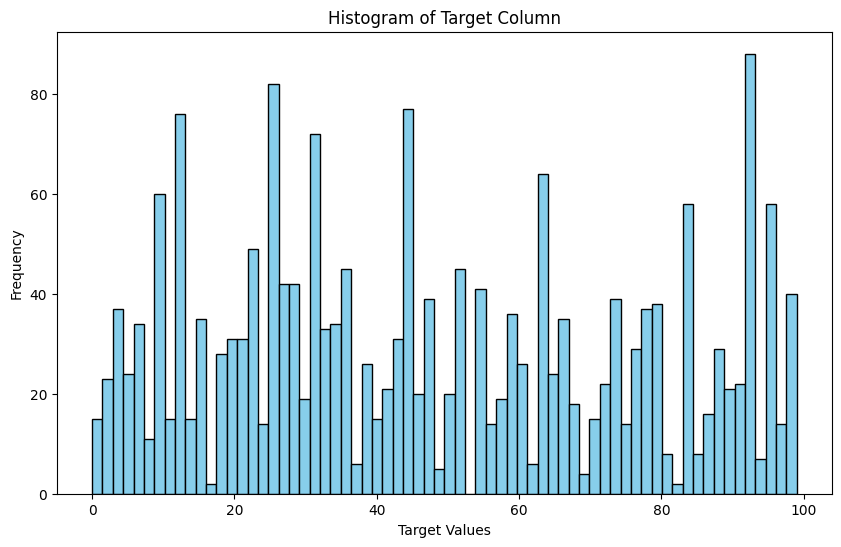

In [60]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [61]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(4.058039729738235, 0.71596, 20904, 29096)

In [62]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(6.505667374038696, 0.4769, 4273, 5727)

In [63]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            


            for d,t in zip(data,target):
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    
                    if(softmax_d<0.8):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1
                elif(decision_mode=='aLL'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))
                    out_0=model_0(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.97):
                        if(softmax_d<0.9 and abs(softmax_F-softmax_T)>0.2):
                            if(softmax_F>softmax_T):
                                outputs.append(out_F)
                                sum_F+=1
                            else:
                                outputs.append(out_T)
                                sum_T+=1
                        elif(softmax_d>=0.9 and abs(softmax_F-softmax_T)<=0.2):
                            if(pred==0):
                                outputs.append(model_F(d.unsqueeze(0)))
                                sum_F+=1
                            else:
                                outputs.append(model_T(d.unsqueeze(0)))
                                sum_T+=1
                        else:
                            outputs.append((out_F + out_T + out_0) / 3.0)
                    else:
                        outputs.append(out_0)

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T


In [64]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_train_loss,total_train_accu,sum_F,sum_T

(1.4847289378070831, 0.83304, 19252, 30748)

In [65]:

total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='aLL')
total_valid_loss,total_valid_accu,sum_F,sum_T

(2.9455048820495606, 0.5455, 1655, 2438)

In [66]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classaccu', [55, 72, 80, 35, 3, 50, 4, 46, 44, 11, 93, 10, 65, 64, 74, 98, 25, 47, 92, 29, 77, 78, 79, 15, 22, 19, 38, 2, 73, 84, 59, 18, 67, 13, 33, 42, 32, 45, 30, 97])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.737061,0.789800,1.796136,0.548800
1,Model_Decision,0.189374,0.928800,0.501765,0.797400
2,Model_T,0.293960,0.914333,1.108069,0.712667
3,Model_F,0.517210,0.851200,1.864264,0.528250
4,Total_Model,1.484729,0.833040,2.945505,0.545500
5,Total_Model_with_perfect_decision,0.382919,0.890960,1.410547,0.638900


In [67]:
model_0 

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

In [68]:
# 定义钩子函数来保存特定层的输出
def save_feature_output(module, input, output):
    global feature_output
    feature_output = output

In [69]:
model_0

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

In [70]:
# 选择特定层并注册钩子函数
layer = model_0.features[16]  # 例如提取第12层的输出
hook = layer.register_forward_hook(save_feature_output)

In [71]:
# 移动模型到GPU（如果可用）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_0.to(device)

# 用于按类别存储特征输出的字典
category_feature_outputs = {i: [] for i in range(100)}  # CIFAR-100 有 100 个类别

# 处理训练集中的所有批次
model_0.eval()  # 设置模型为评估模式
with torch.no_grad():
    for data, target,decision_target,idx in train_dl:
        data,target,decision_target=data.float().to(device),target.to(device),decision_target.to(device)  #將data、target放到gpu上                

        # 前向传播
        _ = model_0(data)

        # 获取特征层的输出
        batch_feature_output = feature_output.cpu().numpy()
        batch_feature_output = batch_feature_output.reshape(batch_feature_output.shape[0], -1)
        
        # 按类别存储特征输出
        for i, label in enumerate(target):
            category_feature_outputs[label.item()].append(batch_feature_output[i])
        
# 将每个类别的特征输出拼接起来
for category in category_feature_outputs:
    if category_feature_outputs[category]:
        category_feature_outputs[category] = np.stack(category_feature_outputs[category], axis=0)
    else:
        category_feature_outputs[category] = np.array([])

# 打印每个类别的特征输出形状
for category, features in category_feature_outputs.items():
    print(f"Category {category}: Feature output shape {features.shape}")

# # 移除钩子
# hook.remove()

Category 0: Feature output shape (500, 2048)
Category 1: Feature output shape (500, 2048)
Category 2: Feature output shape (500, 2048)
Category 3: Feature output shape (500, 2048)
Category 4: Feature output shape (500, 2048)
Category 5: Feature output shape (500, 2048)
Category 6: Feature output shape (500, 2048)
Category 7: Feature output shape (500, 2048)
Category 8: Feature output shape (500, 2048)
Category 9: Feature output shape (500, 2048)
Category 10: Feature output shape (500, 2048)
Category 11: Feature output shape (500, 2048)
Category 12: Feature output shape (500, 2048)
Category 13: Feature output shape (500, 2048)
Category 14: Feature output shape (500, 2048)
Category 15: Feature output shape (500, 2048)
Category 16: Feature output shape (500, 2048)
Category 17: Feature output shape (500, 2048)
Category 18: Feature output shape (500, 2048)
Category 19: Feature output shape (500, 2048)
Category 20: Feature output shape (500, 2048)
Category 21: Feature output shape (500, 2048

In [145]:
class_0_features = category_feature_outputs[0]
len(class_0_features)

500

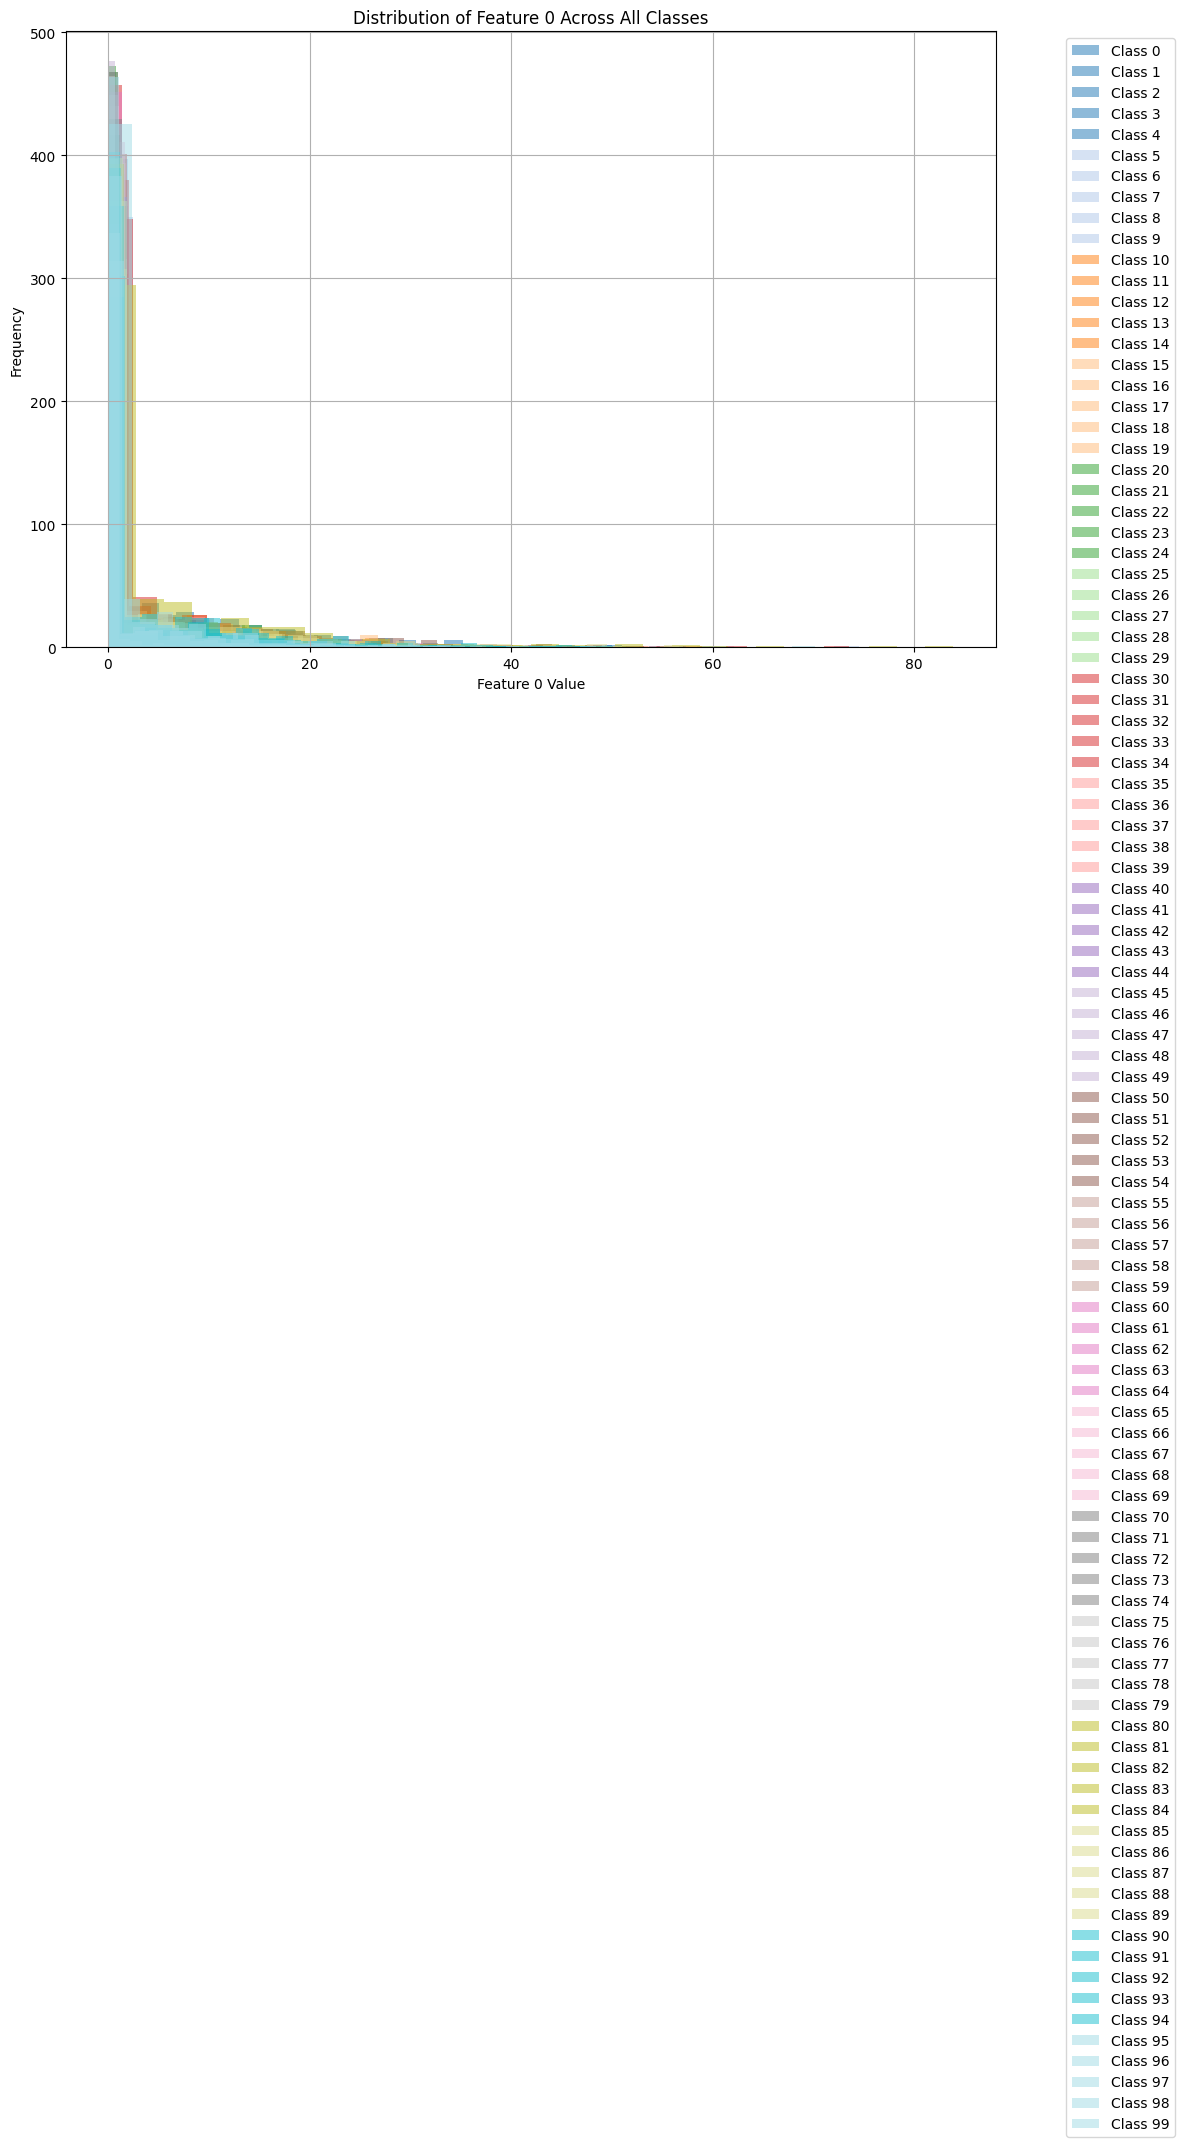

Class 0 histogram counts: [294.  19.  14.  22.  16.  20.  23.  14.  10.  15.   9.   5.   5.   4.
   8.   3.   2.   1.   6.   1.   2.   0.   1.   1.   2.   0.   2.   0.
   0.   1.]
Class 1 histogram counts: [243.  30.  36.  26.  29.  19.  16.  18.  10.  15.  14.   4.  10.   2.
   6.   3.   3.   6.   2.   1.   3.   1.   1.   0.   0.   0.   0.   0.
   0.   2.]
Class 2 histogram counts: [293.  15.  16.  20.  14.  13.  18.  11.   7.  11.  13.  18.   7.   4.
   6.   5.   3.   4.   7.   1.   3.   1.   4.   1.   0.   2.   0.   2.
   0.   1.]
Class 3 histogram counts: [399.  15.  14.  12.  11.   5.   9.   4.   7.   0.   4.   4.   0.   4.
   1.   1.   3.   1.   2.   1.   0.   0.   0.   0.   0.   0.   1.   0.
   0.   2.]
Class 4 histogram counts: [404.  13.  11.   7.   9.  11.   7.   6.   6.   1.   5.   0.   4.   5.
   2.   3.   2.   1.   0.   1.   0.   0.   0.   0.   1.   0.   0.   0.
   0.   1.]
Class 5 histogram counts: [350.  24.  18.  24.  19.   9.  12.   9.   8.   6.   6.   4.   3.   0.
   

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 category_feature_outputs 是一个包含 100 个类别特征的列表或数组
# 其中每个类别特征是一个二维数组，包含该类别所有样本的特征

# 创建一个字典来存储每个类别的直方图计数
hist_counts = {}

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20', 100)  # 使用tab20颜色图，共100种颜色

for category in range(100):
    class_features = category_feature_outputs[category]
    if class_features.size != 0:
        feature_0_values = class_features[:, 0]
        
        # 计算直方图并绘制
        counts, bins, _ = plt.hist(feature_0_values, bins=30, alpha=0.5, label=f'Class {category}', color=colors(category))
        
        # 将计数存储到字典中
        hist_counts[category] = counts

plt.title('Distribution of Feature 0 Across All Classes')
plt.xlabel('Feature 0 Value')
plt.ylabel('Frequency')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), ncol=1)  # 调整图例位置和布局
plt.grid(True)
plt.show()

# 输出每个类别的直方图计数
for category, counts in hist_counts.items():
    print(f'Class {category} histogram counts: {counts}')

In [75]:
del sum

0.9840600000000003


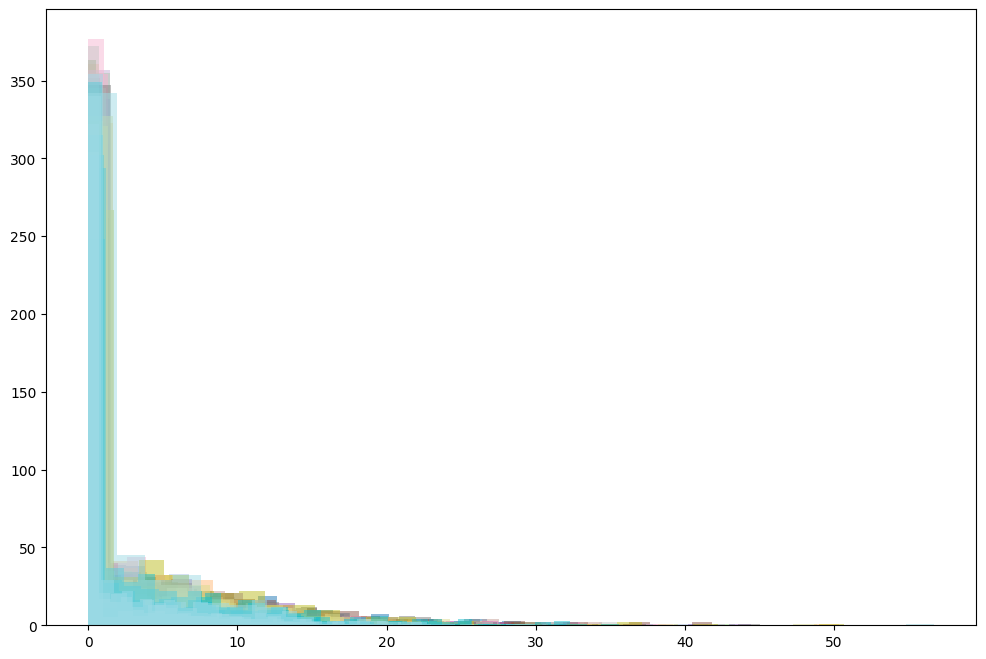

In [147]:
import matplotlib.pyplot as plt
import numpy as np


# 假设 category_feature_outputs 是一个包含 100 个类别特征的列表或数组
# 其中每个类别特征是一个二维数组，包含该类别所有样本的特征

# 创建一个字典来存储每个类别的直方图计数
hist_counts = {}
bin_edges = None
total_samples = sum([len(category_feature_outputs[category]) for category in range(100)])

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20', 100)  # 使用tab20颜色图，共100种颜色

for category in range(100):
    class_features = category_feature_outputs[category]
    if class_features.size != 0:
        feature_0_values = class_features[:, 0]
        
        # 计算直方图并绘制
        counts, bins, _ = plt.hist(feature_0_values, bins=30, alpha=0.5, label=f'Class {category}', color=colors(category))
        
        # 将计数存储到字典中
        hist_counts[category] = counts
        if bin_edges is None:
            bin_edges = bins  # 记录一次bin的边界，假设所有类的边界相同
    hist_counts[category]/=total_samples       
    # print(hist_counts[category],'---')

delta_F = 0
H_n_ab = np.array([hist_counts[category] for category in range(100)])
sum_H_n_ab = np.sum(H_n_ab,axis=0)
max_H_n_ab = np.max(H_n_ab,axis=0)
delta_F = sum_H_n_ab - max_H_n_ab

print(sum(delta_F))



